In [1]:
import dataclasses

@dataclasses.dataclass
class Tile:
    qubits: list[complex]
    color: str



In [4]:
def make_color_code_tiles(*, base_data_width: int) -> list[Tile]:
    if not (base_data_width % 2 == 1 and base_data_width >= 3):
        raise ValueError(f"{base_data_width=} wasn't an odd number at least as large as 3.")
    w = base_data_width * 2 - 1

    def is_in_bounds(q: complex) -> bool:
        # Check that it's within the intersection of the three boundary half planes.
        if q.imag < 0:
            # Too far up.
            return False
        if q.imag * 2 > q.real * 3:
            # Too far downleft.
            return False
        if q.imag * 2 > (w - q.real) * 3:
            # Too far downright.
            return False
        return True

    # Make a hexagonal tiling, cutting away any vertices that are out of bounds.
    tiles = []
    hexagon_offsets = [-1, +1j, +1j + 1, +2, -1j + 1, -1j]
    for x in range(1, w, 2):
        for y in range((x // 2) % 2, w, 2):
            q = x + 1j * y
            tile = Tile(
                color=['red', 'green', 'blue'][y % 3],
                qubits=[
                    q + d
                    for d in hexagon_offsets
                    if is_in_bounds(q + d)
                ],
            )
            # Only keep the hexagons and trapezoids.
            # No empty tiles, or single-point tiles, or etc.
            if len(tile.qubits) in [4, 6]:
                tiles.append(tile)

    return tiles    

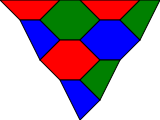

In [5]:
class ShowAsSvg:
    def __init__(self, svg: str):
        self.svg = svg
    def _repr_svg_(self) -> str:
        return self.svg

def draw_tiles_as_svg(tiles: list[Tile]) -> ShowAsSvg:
    # Size the SVG to fit the tiles.
    max_r = max(q.real for tile in tiles for q in tile.qubits)
    max_i = max(q.imag for tile in tiles for q in tile.qubits)
    svg = f'<svg width="{max_r * 20}" height="{max_i * 20}" xmlns="http://www.w3.org/2000/svg">\n'

    # Add each tile to the SVG as a filled shape.
    for tile in tiles:
        pts = [q * 20 for q in tile.qubits]
        p = pts[-1]
        d = f'M{p.real},{p.imag}'
        for p in pts:
            d += f' L{p.real},{p.imag}'
        svg += f'<path d="{d}" fill="{tile.color}" stroke="black" />\n'
    
    svg += '</svg>'
    
    return ShowAsSvg(svg)

draw_tiles_as_svg(make_color_code_tiles(base_data_width=5))

In [7]:
import stim
from typing import Literal

def make_color_code_circuit(
    *,
    obs_basis: Literal['X', 'Y', 'Z'],
    base_data_width: int,
    rounds: int,
    noise_strength: float,
) -> stim.Circuit:
    """Creates a color code circuit with a phenomenological noise model.

    The circuit's detectors are annotated so that Chromobius can decode them.

    Args:
        obs_basis: The basis of the observable to prepare and verify at the end of the circuit.
        base_data_width: The number of data qubits along one side of the patch.
        rounds: The number of times to apply depolarizing noise. One more than the number of
            times to apply measurement noise.
        noise_strength: The strength of the depolarizing noise applied to the data qubits,
            and also the probability of noisy measurements reporting the wrong result.

    Returns:
        The created circuit.
    """

    def mpp_targets(
        qubits: list[complex],
        basis: Literal['X', 'Y', 'Z']
    ) -> list[stim.GateTarget]:
        """Makes a pauli product for an MPP instruction."""
        target_b = {'X': stim.target_x, 'Y': stim.target_y, 'Z': stim.target_z}[basis]
        indices = sorted(q2i[q] for q in qubits)
        targets = []
        for k in indices:
            targets.append(target_b(k))
            targets.append(stim.target_combiner())
        targets.pop()
        return targets

    def measure_observables() -> stim.Circuit:
        """Make instructions to measure an observable of the color code."""
        c = stim.Circuit()
        c.append("MPP", mpp_targets(sorted_qubits, obs_basis))
        c.append("OBSERVABLE_INCLUDE", stim.target_rec(-1), 0)
        return c
        
    def measure_stabilizers(
        *,
        data_noise_after: bool,
        measure_noise: bool,
        include_detectors: bool,
    ) -> stim.Circuit:
        """Make instructions to measure the stabilizers of the color code."""
        c = stim.Circuit()

        # Measure every stabilizer.
        for basis in ['X', 'Z']:
            for tile in tiles:
                c.append("MPP", mpp_targets(tile.qubits, basis), noise_strength if measure_noise else None)
        
        # Compare the measurements to the previous round to produce detection events.
        if include_detectors:
            num_stabilizers = len(tiles) * 2
            for xz in range(2):
                for k, tile in enumerate(tiles):
                    center = sum(tile.qubits) / len(tile.qubits)
                    chromobius_color = {'red': 0, 'green': 1, 'blue': 2}[tile.color]
                    chromobius_annotation = chromobius_color + xz*3
                    offset = xz * len(tiles) + k
                    c.append("DETECTOR", [
                        stim.target_rec(-num_stabilizers + offset), 
                        stim.target_rec(-num_stabilizers*2 + offset),
                    ], [center.real, center.imag, 0, chromobius_annotation])

        # End the round.
        if data_noise_after:
            c.append("DEPOLARIZE1", range(len(all_qubits)), noise_strength)
        c.append("SHIFT_COORDS", [], [0, 0, 1])
        c.append("TICK")

        return c

    tiles = make_color_code_tiles(base_data_width=base_data_width)
    circuit = stim.Circuit()

    # Index the qubit coordinates and put coordinate data in the circuit.
    all_qubits = {q for tile in tiles for q in tile.qubits}
    sorted_qubits = sorted(all_qubits, key=lambda q: (q.real, q.imag))
    q2i = {q: i for i, q in enumerate(sorted_qubits)}
    for q, i in q2i.items():
        circuit.append("QUBIT_COORDS", [i], [q.real, q.imag])

    # Use the helper methods you just defined to build the rounds and combine them into a full circuit.
    circuit += measure_observables()
    circuit += measure_stabilizers(data_noise_after=True, measure_noise=False, include_detectors=False)
    circuit += (rounds - 1) * measure_stabilizers(data_noise_after=True, measure_noise=True, include_detectors=True)
    circuit += measure_stabilizers(data_noise_after=False, measure_noise=False, include_detectors=True)
    circuit += measure_observables()
    
    return circuit

make_color_code_circuit(
    obs_basis='X',
    base_data_width=3,
    rounds=2,
    noise_strength=1e-3
)

stim.Circuit('''
    QUBIT_COORDS(0, 0) 0
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 1) 2
    QUBIT_COORDS(2, 3) 3
    QUBIT_COORDS(3, 0) 4
    QUBIT_COORDS(3, 2) 5
    QUBIT_COORDS(4, 0) 6
    MPP X0*X1*X2*X3*X4*X5*X6
    OBSERVABLE_INCLUDE(0) rec[-1]
    MPP X0*X1*X2*X4 X1*X2*X3*X5 X2*X4*X5*X6 Z0*Z1*Z2*Z4 Z1*Z2*Z3*Z5 Z2*Z4*Z5*Z6
    DEPOLARIZE1(0.001) 0 1 2 3 4 5 6
    SHIFT_COORDS(0, 0, 1)
    TICK
    MPP(0.001) X0*X1*X2*X4 X1*X2*X3*X5 X2*X4*X5*X6 Z0*Z1*Z2*Z4 Z1*Z2*Z3*Z5 Z2*Z4*Z5*Z6
    DETECTOR(1.5, 0.5, 0, 0) rec[-6] rec[-12]
    DETECTOR(2, 1.75, 0, 2) rec[-5] rec[-11]
    DETECTOR(3, 0.75, 0, 1) rec[-4] rec[-10]
    DETECTOR(1.5, 0.5, 0, 3) rec[-3] rec[-9]
    DETECTOR(2, 1.75, 0, 5) rec[-2] rec[-8]
    DETECTOR(3, 0.75, 0, 4) rec[-1] rec[-7]
    DEPOLARIZE1(0.001) 0 1 2 3 4 5 6
    SHIFT_COORDS(0, 0, 1)
    TICK
    MPP X0*X1*X2*X4 X1*X2*X3*X5 X2*X4*X5*X6 Z0*Z1*Z2*Z4 Z1*Z2*Z3*Z5 Z2*Z4*Z5*Z6
    DETECTOR(1.5, 0.5, 0, 0) rec[-6] rec[-12]
    DETECTOR(2, 1.75, 0, 2) rec[-5] rec

In [2]:
import sys
import os
# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))

In [3]:
from src.color_code_utils.color_code_circuits.color_code_circuit_666 import ColorCodeCircuit666

In [10]:
circobj = ColorCodeCircuit666(9,5,1e-3)
circuit = circobj.circuit
print(circuit)
circuit.diagram('detslice-with-ops-svg')
print(circobj.qubits)
print(circobj.ancilla)

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(2, 2) 3
QUBIT_COORDS(3, 1) 4
QUBIT_COORDS(3, 3) 5
QUBIT_COORDS(4, 0) 6
QUBIT_COORDS(4, 2) 7
QUBIT_COORDS(4, 4) 8
QUBIT_COORDS(5, 1) 9
QUBIT_COORDS(5, 3) 10
QUBIT_COORDS(5, 5) 11
QUBIT_COORDS(6, 0) 12
QUBIT_COORDS(6, 2) 13
QUBIT_COORDS(6, 4) 14
QUBIT_COORDS(6, 6) 15
QUBIT_COORDS(7, 1) 16
QUBIT_COORDS(7, 3) 17
QUBIT_COORDS(7, 5) 18
QUBIT_COORDS(7, 7) 19
QUBIT_COORDS(8, 0) 20
QUBIT_COORDS(8, 2) 21
QUBIT_COORDS(8, 4) 22
QUBIT_COORDS(8, 6) 23
QUBIT_COORDS(8, 8) 24
QUBIT_COORDS(9, 1) 25
QUBIT_COORDS(9, 3) 26
QUBIT_COORDS(9, 5) 27
QUBIT_COORDS(9, 7) 28
QUBIT_COORDS(9, 9) 29
QUBIT_COORDS(10, 0) 30
QUBIT_COORDS(10, 2) 31
QUBIT_COORDS(10, 4) 32
QUBIT_COORDS(10, 6) 33
QUBIT_COORDS(10, 8) 34
QUBIT_COORDS(10, 10) 35
QUBIT_COORDS(11, 1) 36
QUBIT_COORDS(11, 3) 37
QUBIT_COORDS(11, 5) 38
QUBIT_COORDS(11, 7) 39
QUBIT_COORDS(11, 9) 40
QUBIT_COORDS(11, 11) 41
QUBIT_COORDS(12, 0) 42
QUBIT_COORDS(12, 2) 43
QUBIT_COORDS(12, 4) 44
QUB

In [6]:
import stim
import chromobius
import numpy as np
from qectostim.decoders import chromobius_decoder, decoder_selector

In [28]:
sampler = circuit.compile_detector_sampler()
dem = circuit.detector_error_model()
dem.diagram("matchgraph-svg")
#circuit.diagram('detslice-with-ops-svg', tick=range(15, 25), filter_coords=['D8', 'D11', ])
cd = decoder_selector.select_decoder(dem, 'chromobius')

dets, actual_obs = sampler.sample(shots=10_000, separate_observables=True, bit_packed=False)

dec = cd.decode_batch(dets)
mismatches = np.count_nonzero(np.any(actual_obs != dec, axis=1))
print(mismatches/10_000)

0.0005


In [16]:
decoder = chromobius.compile_decoder_for_dem(dem)

In [7]:
dets, actual_obs = sampler.sample(shots=1024, separate_observables=True, bit_packed=True)
predicted_obs = decoder.predict_obs_flips_from_dets_bit_packed(dets)
mistake = np.count_nonzero(np.any(predicted_obs != actual_obs, axis=1))
print(f'actual: {actual_obs} \n predicted: {predicted_obs}')

actual: [[1]
 [0]
 [0]
 ...
 [0]
 [1]
 [0]] 
 predicted: [[1]
 [0]
 [0]
 ...
 [0]
 [1]
 [0]]


In [24]:
with open('testcirc.txt') as f:
    c = f.read()
circ = stim.Circuit(c)
dem2 = circ.detector_error_model()

#cd = decoder_selector.select_decoder(dem2)

#sampler2 = circ.compile_detector_sampler()
#dets, actual_obs = sampler2.sample(shots=1024, separate_observables=True, bit_packed=False)

#cd.decode_batch(dets)
import webbrowser


# 2. Find a specific error mechanism (e.g., a hook error)
# This looks for a specific failure mechanism in the Detector Error Model
#dem = circ.detector_error_model(decompose_errors=True)

# 3. Explain it!
# This function finds the error chain that causes a specific set of detection events
# You can just grab the first error in the model to see how it works
explanation = circ.explain_detector_error_model_errors(
    dem_filter=dem2, 
    reduce_to_one_representative_error=True
)

# 4. Generate the visualization URL
# This will print a URL you can paste into your browser to see the error in 3D/2D
for error in explanation:
    url = error.crimped_url()  # Generates a 'Crumble' URL
    print("Click this to see the hook error:", url)
    # webbrowser.open(url) # Uncomment to auto-open

AttributeError: 'stim._stim_sse2.ExplainedError' object has no attribute 'crimped_url'

In [34]:
def count_logical_errors(circuit:stim.Circuit, num_shots:int):
    #sample the circuit
    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    detector_error_model = circuit.detector_error_model()
    decoder = chromobius.commpile_decoder_for_dem(detector_error_model)

    #run the decoder
    predictions = decoder.predict_obs_flips_from_dets_bit_packed(detection_events)

    num_errors = int(np.count_nonzero(np.any(predictions != observable_flips, axis=1)))
    return num_errors / num_shots

In [5]:
import sinter

tasks = [
    sinter.Task(
        circuit=ColorCodeCircuit666(d,r).circuit,
        json_metadata={'d': d, 'p': p, 'r': r, 'b': b},
    )
    for d in [3, 5, 7, 9]
    for r in [d*4]
    for b in ['X']
    for p in [0.01, 0.02]
]

stats = sinter.collect(
    tasks=tasks,
    num_workers=os.cpu_count(),
    max_shots=100_000,
    max_errors=100,
    print_progress=True,
    decoders=['chromobius'],
    custom_decoders=chromobius.sinter_decoders(),
)

NameError: name 'chromobius' is not defined

Starting 4 workers...
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata       
        4 chromobius <1m      99983          98 d=5,p=0.001,r=15,b=Z
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata       
        4 chromobius <1m      98908           9 d=5,p=0.001,r=15,b=Z
1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata       
        4 chromobius [draining]      97884         -97 d=5,p=0.001,r=15,b=Z
1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata       
        4 chromobius [draining]      94812        -392 d=5,p=0.001,r=15,b=Z


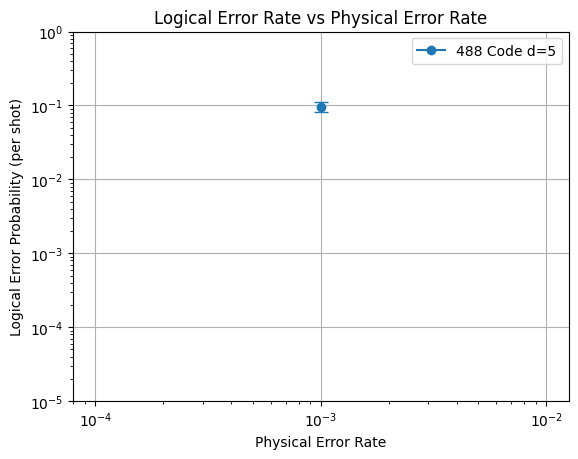

In [44]:
from src.color_code_utils.color_code_circuits.color_code_circuit_488 import ColorCodeCircuit488
import matplotlib.pyplot as plt

with open("sample488.txt") as f:
    c = f.read()

tasks = [
    sinter.Task(
        circuit=stim.Circuit(c),
        json_metadata={'d': d, 'p': p, 'r': r, 'b': b},
    )
    for d in [5]
    for r in [15]
    for b in ['Z']
    for p in [0.001]
]

stats = sinter.collect(
    tasks=tasks,
    num_workers=os.cpu_count(),
    max_shots=100_000,
    max_errors=100,
    print_progress=True,
    decoders=['chromobius'],
    custom_decoders=chromobius.sinter_decoders(),
)
# Render a matplotlib plot of the data.
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    group_func=lambda stat: f"488 Code d={stat.json_metadata['d']}",
    x_func=lambda stat: stat.json_metadata['p'],
)
ax.loglog()
ax.set_ylim(1e-5, 1)
ax.grid()
ax.set_title('Logical Error Rate vs Physical Error Rate')
ax.set_ylabel('Logical Error Probability (per shot)')
ax.set_xlabel('Physical Error Rate')
ax.legend()

# Save to file and also open in a window.
fig.savefig('plot.png')
plt.show()

In [15]:
def process_circuit(distance, capacity, gate_improvements, num_shots):
    logger = get_logger()
    logger.setLevel(logging.INFO)
    handler = logging.FileHandler("process_log.txt")
    formatter = logging.Formatter('%(processName)s - %(levelname)s - %(message)s')
    handler.setFormatter(formatter)
    logger.addHandler(handler)

    logger.info(f"Starting circuit generation for distance {distance} and capacity {capacity}")
  
    circuit = QCCDCircuit.generated(
        "surface_code:rotated_memory_z",
        rounds=1,
        distance=distance,
    )
    nqubitsNeeded = 2 * distance**2 - 1

    nrowsNeeded = int(np.sqrt(nqubitsNeeded))+2

    logger.info(f"Processing circuit with {nqubitsNeeded} qubits and {nrowsNeeded} rows")

    arch, (instructions, _) = circuit.processCircuitAugmentedGrid(rows=nrowsNeeded, cols=nrowsNeeded, trapCapacity=capacity)
    # arch, (instructions, _) = circuit.processCircuitNetworkedGrid(traps=nqubitsNeeded, trapCapacity=capacity)
    arch.refreshGraph()

    results = {"ElapsedTime": {}, "Operations": {}, "MeanConcurrency": {}, "QubitOperations": {}, "LogicalErrorRates": {}, "PhysicalZErrorRates": {}, "PhysicalXErrorRates": {}, "Electrodes": {}, "DACs": {}}

    # FIXME legacy formatting!
    label ="Forwarding"

    logger.info(f"Processing operations using {label} for distance {distance} and capacity {capacity}")
    allOps, barriers = ionRouting(arch, instructions, capacity)
 
    parallelOpsMap = paralleliseOperationsWithBarriers(allOps, barriers)
    logicalErrors = []
    physicalZErrors = []
    physicalXErrors = []
    
    for gate_improvement in gate_improvements:
        logicalError, physicalXError, physicalZError = circuit.simulate(allOps, num_shots=num_shots, error_scaling=gate_improvement)
        logicalErrors.append(logicalError)
        physicalZErrors.append(physicalZError)
        physicalXErrors.append(physicalXError)

    logger.info(f"Simulated {label} method with gate improvements for distance {distance}, capacity {capacity}")
    
    
    for op in parallelOpsMap.values():
        op.calculateOperationTime()
        op.calculateFidelity()

    circuit.resetArch()
    arch.refreshGraph()

    results["Capacity"] = capacity
    results["Distance"] = distance
    results["ElapsedTime"][label] = max(parallelOpsMap.keys())
    results["Operations"][label] = len(allOps)
    results["MeanConcurrency"][label] = np.mean([len(op.operations) for op in parallelOpsMap.values()])
    results["QubitOperations"][label] = len(instructions)
    results["LogicalErrorRates"][label] = logicalErrors
    results["PhysicalZErrorRates"][label] = physicalZErrors
    results["PhysicalXErrorRates"][label] = physicalXErrors


    trapSet = set()
    junctionSet = set()
    for op in allOps:
        for c in op.involvedComponents:
            if isinstance(c, Trap):
                trapSet.add(c)
            elif isinstance(c, Junction):
                junctionSet.add(c)

    # Every zone can contain up to two qubits
    # Njz = 1*Nj, Nlz = Nl*k
    # The number of zones  N = 1*Nj+k*Nl
    Njz = len(junctionSet) # each junction is one zone
    Nlz = len(trapSet)*capacity # each trap is k zones

    # Njz = int(np.ceil(nqubitsNeeded / (2*(capacity-1))) )# 2 traps per junction
    # Nlz = nqubitsNeeded-Njz
    Nde = NDE_LZ*Nlz+NDE_JZ*Njz
    Nse = NSE_Z*(Njz+Nlz)

    Num_electrodes = Nde+Nse
    Num_DACs = Num_electrodes
    results["DACs"][label] = Num_DACs
    results["Electrodes"][label] = Num_electrodes

    logger.info(f"{distance} {capacity} {label} = {results}")
    
    logger.info(f"Finished processing for distance {distance} and capacity {capacity}")
    return results

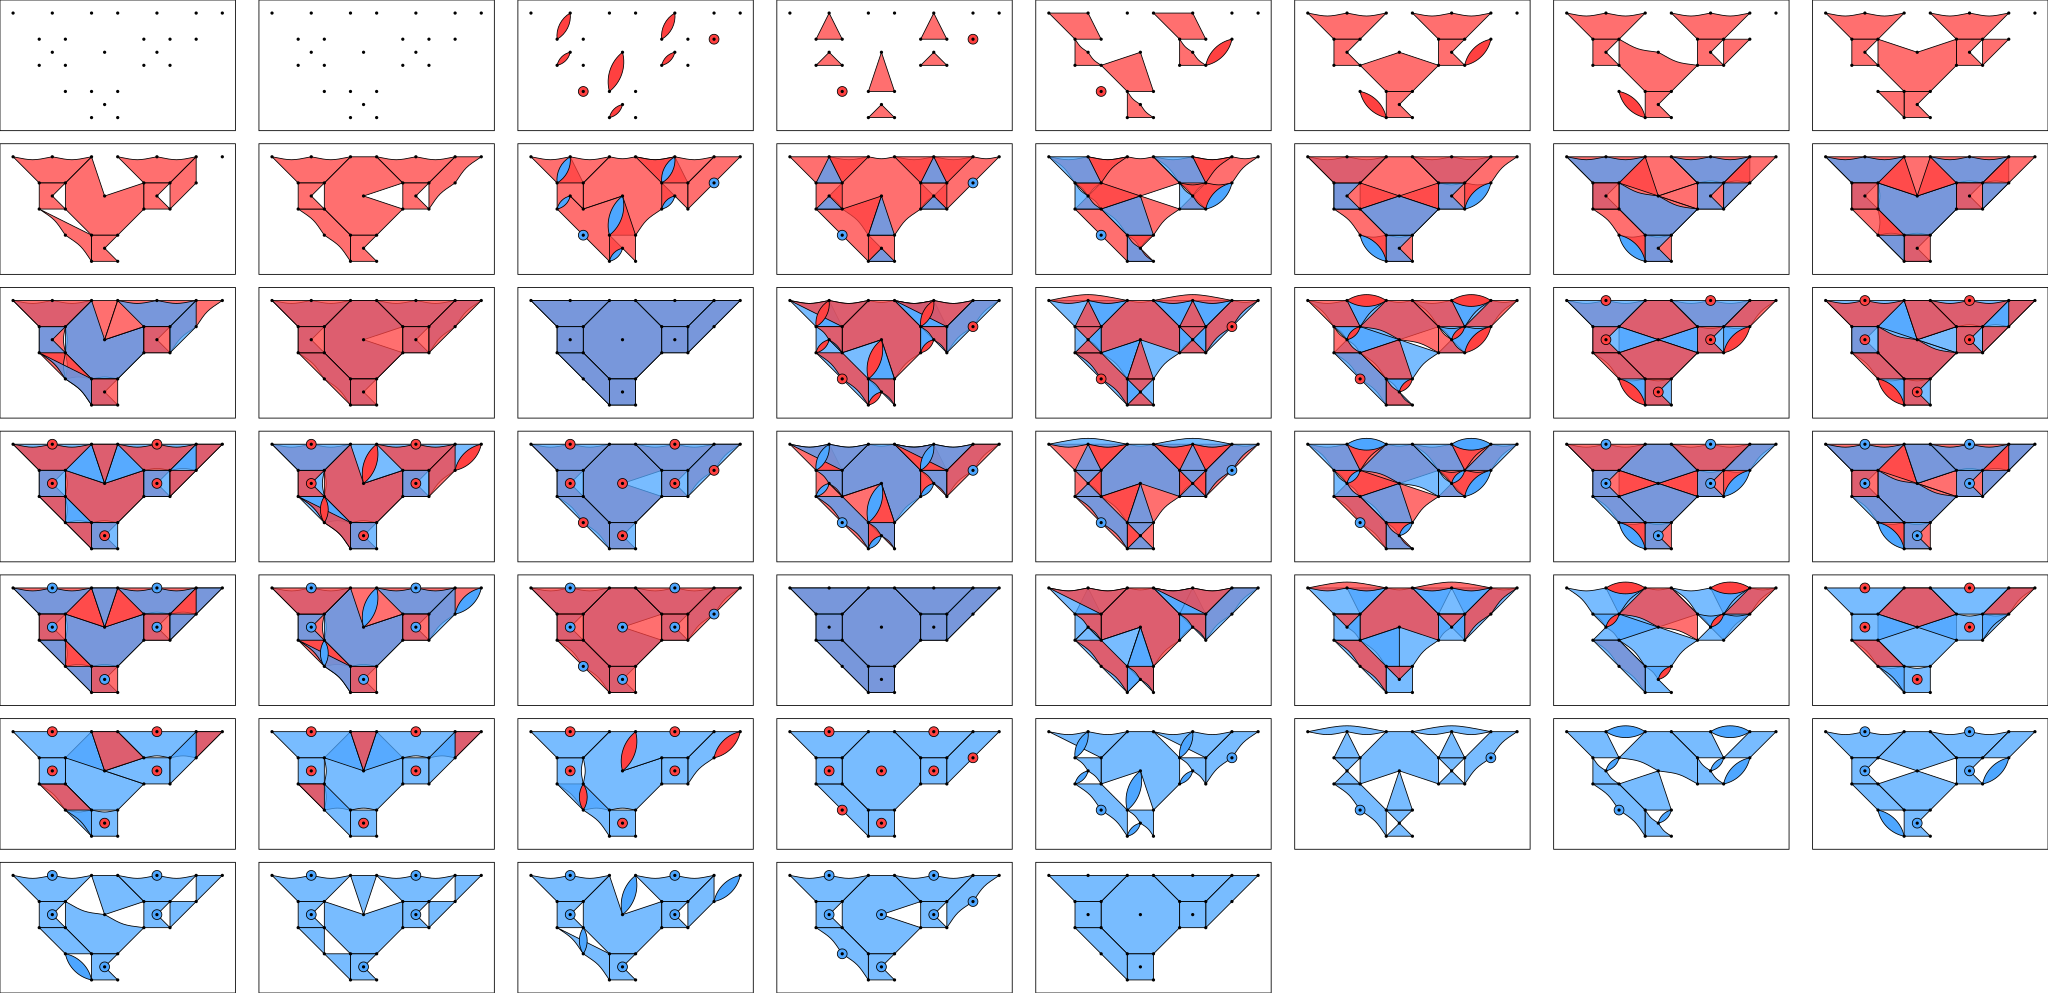

In [28]:
circuit=ColorCodeCircuit488(5,2,1e-3).get_circuit()
dem = circuit.detector_error_model()
explanation = circuit.explain_detector_error_model_errors(
    dem_filter=dem, 
    reduce_to_one_representative_error=True
)
#print(explanation)
#dem.diagram("matchgraph-3d")
circuit.diagram("detslice")